In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [6]:
rate_col = "Cardio Rate"

In [7]:
design_matrix_otrain[rate_col].mean()

0.16251911764705876

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

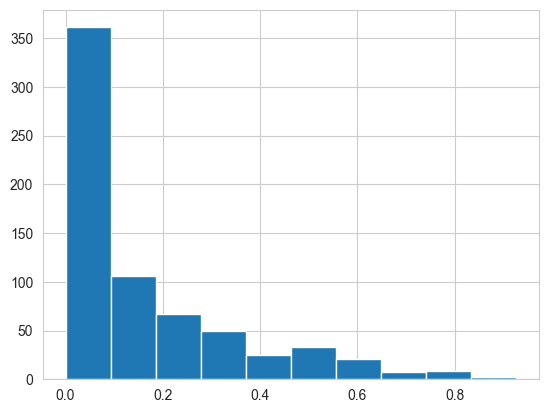

In [9]:
design_matrix_train[rate_col].hist(bins=10)

In [10]:
design_matrix_train

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,coag1,cns1,liv1,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate,group
0,0,SA_BOX_1-462_S1-C8_1_6848,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,...,-0.231340,0.183683,-0.358644,0.067,0.000,0.000,0.000,0.000,0.000,1
1,1,SA_BOX_9-2606_S1-A5_1_6136,-1.577464,-0.128251,0.216787,0.322727,1.041185,1.0,-1.451047,-0.037510,...,-1.999547,0.107765,-0.303266,0.097,0.089,0.094,0.000,0.000,0.000,1
2,2,SA_BOX_3-2442_S4-H8_1_5579,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,...,-0.230536,0.478683,-0.212750,0.000,0.000,0.000,0.000,0.000,0.000,1
3,3,SA_BOX_2-1644_S2-A10_1_6960,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,...,0.133706,0.276911,0.977512,0.078,0.558,0.000,0.177,0.000,0.000,1
4,4,SA_BOX_4-2435_S5-E11_1_5698,-0.213116,-1.597408,-1.611235,0.394841,1.940465,1.0,-3.109139,-0.188534,...,0.522159,0.233844,0.389574,0.541,0.121,0.084,0.000,0.000,0.092,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,675,SA_BOX_11-2056_S4-F8_1_6362,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,...,-1.515554,0.621018,-0.911881,0.000,0.000,0.000,0.000,0.000,0.000,1
676,676,SA_BOX_3-697_S4-A6_1_5555,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,...,0.099164,0.060904,-1.010263,0.364,0.000,0.187,0.000,0.000,0.023,2
677,677,SA_BOX_8-2367_S5-C12_1_6096,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,...,0.319431,0.448526,1.013194,0.883,0.440,0.030,0.093,0.155,0.000,1
678,678,SA_BOX_4-2564_S5-F11_1_5699,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,...,0.535371,-0.181927,0.392048,0.000,0.000,0.000,0.000,0.000,0.089,1


<Axes: xlabel='Cardio Rate', ylabel='Count'>

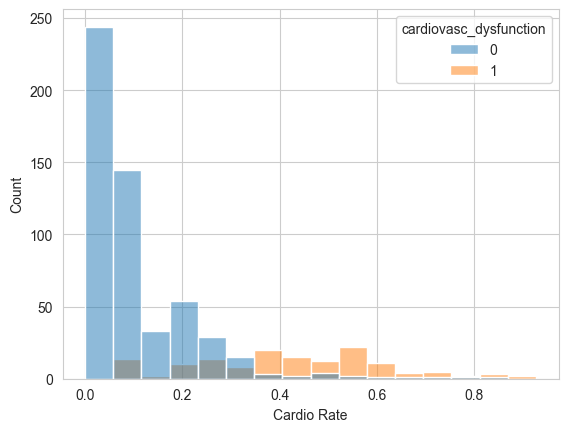

In [11]:
sns.histplot(
    data=design_matrix_train,
    x=rate_col,
    hue="cardiovasc_dysfunction"
)

In [12]:
design_matrix_train['group'].value_counts()

group
1    434
2    246
Name: count, dtype: int64

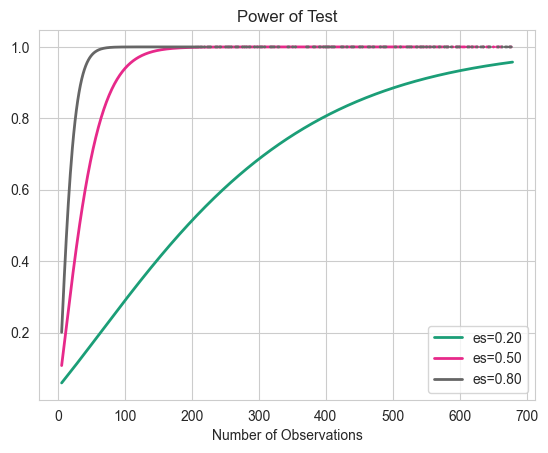

In [13]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [14]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [15]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [16]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [17]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

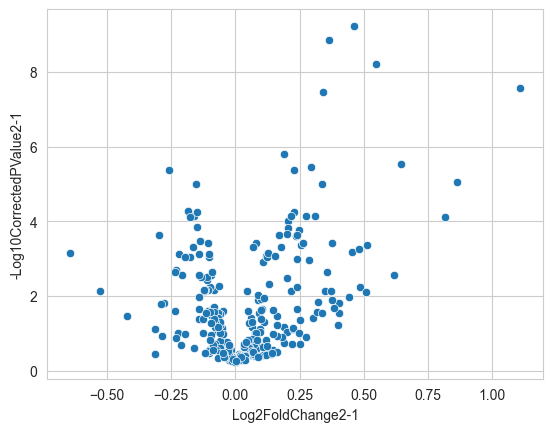

In [18]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [19]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
123,P61769,B2MG_HUMAN,1.082815,12.259813,11.798797,0.914460,0.751114,0.461017,3.465559e-12,246,...,12.652368,10.490738,11.618301,12.289228,11.372313,11.781104,10.906047,11.750655,11.657643,12.220980
144,P19320,VCAM1_HUMAN,0.996925,11.061567,10.697643,0.762178,0.601965,0.363924,1.623631e-11,246,...,11.783156,10.225796,10.592817,11.845488,9.970006,10.625852,10.063482,11.402239,10.674081,10.664370
154,P01033,TIMP1_HUMAN,1.000037,10.679921,10.132154,1.123001,0.997967,0.547766,1.076009e-10,246,...,11.305144,9.690175,10.005689,11.112195,9.291888,10.080163,9.175368,10.305271,10.987082,9.923244
276,Q9Y279,VSIG4_HUMAN,1.282294,7.100447,5.990412,2.274671,2.179123,1.110035,6.327581e-10,246,...,8.632800,3.843913,3.922370,8.381036,3.828391,8.040848,4.412084,8.752571,6.987103,8.367238
230,P01034,CYTC_HUMAN,0.841874,12.371904,12.032075,0.734250,0.658169,0.339829,1.029099e-09,246,...,12.388361,11.367966,11.808035,12.448976,11.842510,12.033297,11.763599,12.130882,11.829693,11.762052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,P23528,COF1_HUMAN,0.006117,8.306096,8.312758,2.193871,2.143383,-0.006662,9.692543e-01,246,...,9.077232,8.580938,9.533280,11.872983,3.439920,9.820595,3.903168,9.592126,11.314706,10.214151
188,P03950,ANGI_HUMAN,0.001995,9.868291,9.870092,0.633305,0.571284,-0.001800,9.697872e-01,246,...,10.055659,9.684060,9.495213,9.651662,8.927222,9.737326,9.481883,10.273815,9.110431,10.043787
157,P05090,APOD_HUMAN,0.001116,15.713147,15.712211,0.493094,0.485999,0.000936,9.808845e-01,246,...,16.175349,15.810826,15.879311,16.941369,15.351709,15.633920,15.631861,16.110138,16.031145,14.966750
122,P00736,C1R_HUMAN,0.000278,13.901741,13.901923,0.310037,0.308536,-0.000182,9.941116e-01,246,...,13.945996,14.433339,14.075713,13.861325,13.497603,14.066628,13.994173,13.330209,14.245951,13.493643


In [20]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [21]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [22]:
protein_columns = training_data.columns.to_list()

In [23]:
len(protein_columns)

287

In [24]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.516260162601626,
 0.46880160962863826,
 0.6132444479097631,
 0.592269608759306,
 0.646052160234246)

In [27]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [61]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
VSIG4_HUMAN,1.528480,1.432531,1.377651,1.446221
CBG_HUMAN,1.254928,0.879477,0.884384,1.006263
CO8G_HUMAN,0.737703,0.683924,1.229936,0.883854
LBP_HUMAN,0.435523,0.652754,0.927846,0.672041
PROZ_HUMAN,0.606899,0.870080,0.482701,0.653227
...,...,...,...,...
PGRP2_HUMAN,0.057420,0.009516,0.064571,0.043836
PROP_HUMAN,0.024840,0.081168,0.017824,0.041277
GPX3_HUMAN,0.082450,0.016814,0.006700,0.035321


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

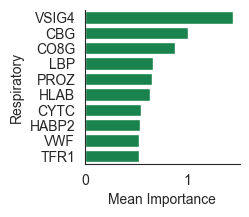

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Cardio"

In [34]:
feature_importance_results.to_csv(
    "cardio_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/cardio_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/cardio_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
